Overall Accuracy : 1.0000
AUC Score        : 1.0000
Confusion Matrix :
[[175   0]
 [  0 185]]


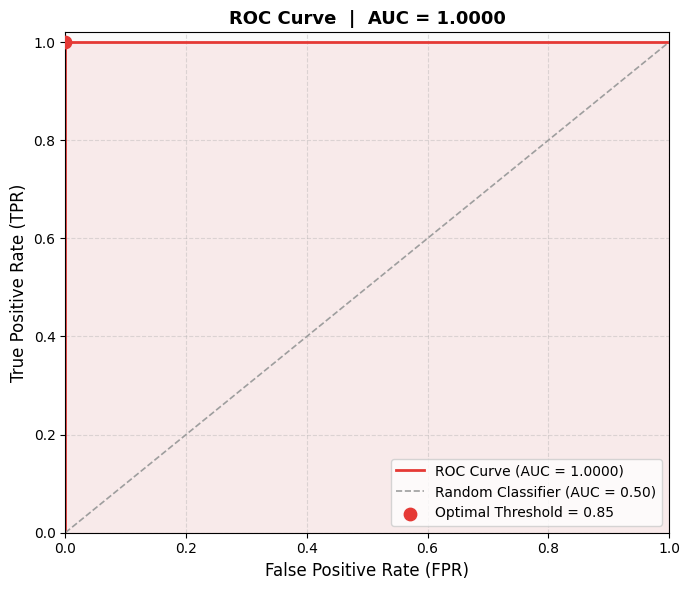

✅ রোক গ্রাফ সেভ হয়েছে: roc_curve_flood.png


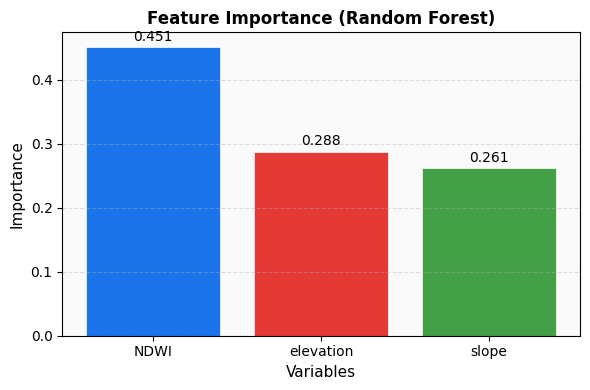

✅ Feature Importance গ্রাফ সেভ হয়েছে


In [1]:
# ============================
# Flood Risk ROC Curve - Colab
# ============================

# Step 1: Install & Import
!pip install scikit-learn matplotlib numpy pandas --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# ============================
# Step 2: GEE থেকে Export করা
# CSV ফাইল লোড করো অথবা
# নিচের synthetic data দিয়ে test করো
# ============================

# Option A: যদি GEE থেকে CSV export করে থাকো
# df = pd.read_csv('/content/sample_points.csv')
# X = df[['NDWI', 'elevation', 'slope']]
# y = df['FloodClass']

# Option B: GEE console data দিয়ে synthetic test
np.random.seed(42)
n = 1200

# Flood class 1 (flooded)
ndwi_flood    = np.random.uniform(0.0,  0.5,  n//2)
elev_flood    = np.random.uniform(4,    12,   n//2)
slope_flood   = np.random.uniform(0,    3,    n//2)

# Flood class 0 (non-flooded)
ndwi_noflood  = np.random.uniform(-0.8, -0.1, n//2)
elev_noflood  = np.random.uniform(10,   20,   n//2)
slope_noflood = np.random.uniform(2,    10,   n//2)

X = pd.DataFrame({
    'NDWI':      np.concatenate([ndwi_flood,  ndwi_noflood]),
    'elevation': np.concatenate([elev_flood,  elev_noflood]),
    'slope':     np.concatenate([slope_flood, slope_noflood])
})
y = np.array([1]*(n//2) + [0]*(n//2))

# ============================
# Step 3: Train/Test Split
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================
# Step 4: Random Forest Train
# ============================
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# ============================
# Step 5: ROC + AUC
# ============================
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Accuracy
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print(f"Overall Accuracy : {acc:.4f}")
print(f"AUC Score        : {roc_auc:.4f}")
print(f"Confusion Matrix :\n{cm}")

# ============================
# Step 6: Plot
# ============================
fig, ax = plt.subplots(figsize=(7, 6))

# ROC Curve
ax.plot(fpr, tpr,
        color='#e53935', lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Reference diagonal
ax.plot([0, 1], [0, 1],
        color='#9e9e9e', lw=1.2,
        linestyle='--',
        label='Random Classifier (AUC = 0.50)')

# Optimal threshold point (closest to top-left)
optimal_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color='#e53935', s=80, zorder=5,
           label=f'Optimal Threshold = {thresholds[optimal_idx]:.2f}')

# Shaded area under ROC
ax.fill_between(fpr, tpr, alpha=0.08, color='#e53935')

# Labels & styling
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title(f'ROC Curve  |  AUC = {roc_auc:.4f}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('roc_curve_flood.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ রোক গ্রাফ সেভ হয়েছে: roc_curve_flood.png")

# ============================
# Step 7: Feature Importance
# ============================
importances = clf.feature_importances_
features    = X.columns.tolist()

fig2, ax2 = plt.subplots(figsize=(6, 4))
colors = ['#1a73e8', '#e53935', '#43a047']
bars = ax2.bar(features, importances, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, importances):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax2.set_title('Feature Importance (Random Forest)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Importance', fontsize=11)
ax2.set_xlabel('Variables', fontsize=11)
ax2.set_facecolor('#fafafa')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature Importance গ্রাফ সেভ হয়েছে")